# Computer Vision

Computer Vision (CV) is a subfield of Artificial Intelligence (AI) that enables computers to 
interpret and understand 
visual information from images, videos, or other visual data.

In essence, CV allows machines to "see" and process visual content in the same way humans do. This involves various tasks, such as:

Computer Vision applications are diverse and widespread:

<pre>
Autonomous vehicles: self-driving cars rely on CV for obstacle detection, lane tracking, and navigation.
Facial recognition: biometric security systems use CV to authenticate identities.
Medical imaging analysis: CV helps doctors diagnose diseases from medical images (e.g., tumor detection).
Object recognition: e-commerce platforms use CV-powered search engines to identify products.
Security surveillance: CV enables monitoring and detecting suspicious behavior in real-time.
</pre>

Image classification - What's in the image

Image segmentation - Which pixels belong to each object?

Object detection - Where is the object? (bounding box)

### Three areas in Computer Vision

1)  Image classification - where the goal is to assign one or more labels to an image. It may be either single-label classification (meaning categories are mutually exclusive) or multilabel classification (tagging all categories that an image belongs to. 

For example, when you search for a keyword on the Google Photos app, behind the scenes you’re querying a very large multilabel classification model — one with over 20,000 different classes, trained on millions of images.


2)  Image segmentation, where the goal is to “segment” or “partition” an image into different areas, with each area usually representing a category.

For instance, when Zoom or Google Meet displays a custom background behind you in a video call, it’s using an image segmentation model to distinguish your face from what’s behind it, with pixel-level precision.

Object detection, where the goal is to draw rectangles (called bounding boxes) around objects of interest in an image and associate each rectangle with a class. A self-driving car could use an object detection model to monitor cars, pedestrians, and signs in view of its cameras, for instance

3)  Object detection -  where the goal is to draw rectangles (called bounding boxes) around objects of interest in an image and associate each rectangle with a class. 

A self-driving car could use an object detection model to monitor cars, pedestrians, and signs in view of its cameras, for instance

<img src="./images/dl_cnn_10.png" width=1000 />

# Image Segmentation

Image segmentation is the task of cutting an image into meaningful pieces, pixel by pixel, so that a computer can understand what is in the image and where it is.

It’s like giving a computer the ability to:

<pre>
	•	Not just recognize that there’s a cat in the picture
	•	But understand exactly which pixels belong to the cat
</pre>

There are three different flavors of image segmentation that you should know about:

1)  Semantic segmentation, where each pixel is independently classified into a semantic category, like “cat.” If there are two cats in the image, the corresponding pixels are all mapped to the same generic “cat” category.

2)  Instance segmentation, which seeks to parse out individual object instances. In an image with two cats in it, instance segmentation would distinguish between pixels belonging to “cat 1” and pixels belonging to “cat 2”.

3)  Panoptic segmentation, which combines semantic segmentation and instance segmentation by assigning to each pixel in an image both a semantic label (like “cat”) and an instance label (like “cat 2”). This is the most informative of all three segmentation types.

<img src="./images/dl_cnn_11.png" width=1000 />

### The Oxford-IIIT Pet Dataset 

https://www.robots.ox.ac.uk/~vgg/data/pets/



37 category pet dataset with roughly 200 images for each class. 

The images have a large variations in scale, pose and lighting. 

All images have an associated ground truth annotation of breed, head ROI, and pixel level trimap segmentation

<img src="./images/dl_cnn_9.png" width=1000 />

In [ ]:
import pathlib

input_dir = pathlib.Path("dataset/images")
target_dir = pathlib.Path("dataset/annotations/trimaps")

# Loads all the input images
input_img_paths = sorted(input_dir.glob("*.jpg"))
# Ignores some spurious files in the trimaps directory that start with
# a "."
target_paths = sorted(target_dir.glob("[!.]*.png"))

In [39]:
print(len(input_img_paths))
print(len(target_paths))

7390
7390


### Peek at an example

<class 'numpy.ndarray'>
(448, 500, 3) 3
[[[ 48. 117. 182.]
  [ 47. 115. 188.]
  [ 48. 115. 186.]
  ...
  [ 93.  81.  39.]
  [ 92.  80.  38.]
  [118. 105.  71.]]

 [[ 48. 118. 187.]
  [ 50. 120. 192.]
  [ 52. 122. 194.]
  ...
  [101.  89.  47.]
  [ 97.  85.  45.]
  [121. 106.  73.]]

 [[ 51. 123. 195.]
  [ 50. 124. 197.]
  [ 51. 128. 200.]
  ...
  [101.  89.  49.]
  [ 97.  83.  46.]
  [116. 101.  70.]]

 ...

 [[223. 201. 151.]
  [201. 174. 121.]
  [195. 162. 108.]
  ...
  [200. 185. 130.]
  [181. 170. 114.]
  [179. 168. 122.]]

 [[221. 201. 150.]
  [197. 174. 120.]
  [187. 158. 102.]
  ...
  [216. 208. 146.]
  [196. 192. 131.]
  [177. 174. 121.]]

 [[213. 196. 150.]
  [192. 170. 121.]
  [184. 156. 106.]
  ...
  [216. 208. 169.]
  [190. 188. 140.]
  [180. 179. 135.]]]


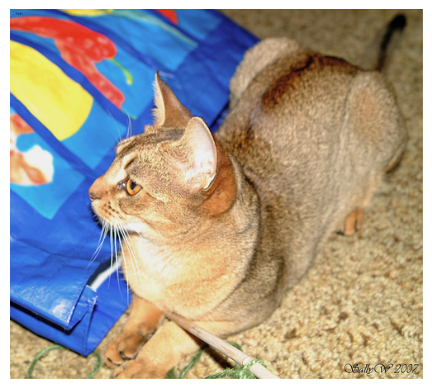

In [33]:
import matplotlib.pyplot as plt
from keras.utils import load_img, img_to_array, array_to_img


img = img_to_array(load_img(input_img_paths[9]))
print(type(img))
print(img.shape, img.ndim)
print(img)

plt.axis("off")
# Displays input image number 9
plt.imshow(load_img(input_img_paths[9]))

For the Oxford-IIIT Pets dataset, the segmentation masks (trimaps) contain 3 classes, encoded as:

1 → foreground (the pet)

2 → background

3 → boundary region

So each pixel in the mask is either 1, 2, or 3.

Step 1: Convert image to array

Step 2: Convert class labels to grayscale intensities 
    1 -> 0, 2 -> 1, 3 -> 2
    0 * 127 - 0 (Black)
    1 * 127 - 127 (Gray)
    2 * 127 - 254 (White)

Step 3: Display the image

3 (448, 500, 1)
[[[2.]
  [2.]
  [2.]
  ...
  [2.]
  [2.]
  [2.]]

 [[2.]
  [2.]
  [2.]
  ...
  [2.]
  [2.]
  [2.]]

 [[2.]
  [2.]
  [2.]
  ...
  [2.]
  [2.]
  [2.]]

 ...

 [[2.]
  [2.]
  [2.]
  ...
  [2.]
  [2.]
  [2.]]

 [[2.]
  [2.]
  [2.]
  ...
  [2.]
  [2.]
  [2.]]

 [[2.]
  [2.]
  [2.]
  ...
  [2.]
  [2.]
  [2.]]]


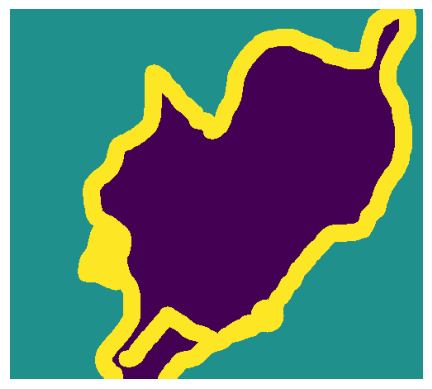

In [36]:
def display_target(target_array):
    # The original labels are 1, 2, and 3. We subtract 1 so that the
    # labels range from 0 to 2, and then we multiply by 127 so that the
    # labels become 0 (black), 127 (gray), 254 (near-white).
    normalized_array = (target_array.astype("uint8") - 1) * 127
    plt.axis("off")
    plt.imshow(normalized_array[:, :, 0])

# We use color_mode='grayscale' so that the image we load is treated as
# having a single color channel.
img = img_to_array(
    load_img(
        target_paths[9], 
        color_mode="grayscale"
    )
)

print(img.ndim, img.shape)
print(img)
display_target(img)

In [37]:
import numpy as np
import random

# We resize everything to 200 x 200 for this example.
img_size = (200, 200)
# Total number of samples in the data
num_imgs = len(input_img_paths)

# Shuffles the file paths (they were originally sorted by breed). We
# use the same seed (1337) in both statements to ensure that the input
# paths and target paths stay in the same order.
random.Random(1337).shuffle(input_img_paths)
random.Random(1337).shuffle(target_paths)

In [40]:
def path_to_input_image(path):
    return img_to_array(load_img(path, target_size=img_size))

def path_to_target(path):
    img = img_to_array(
        load_img(path, target_size=img_size, color_mode="grayscale")
    )
    # Subtracts 1 so that our labels become 0, 1, and 2
    img = img.astype("uint8") - 1
    return img

In [41]:
# Loads all images in the input_imgs float32 array and their masks in
# the targets uint8 array (same order). The inputs have three channels
# (RGB values), and the targets have a single channel (which contains
# integer labels).
input_imgs = np.zeros((num_imgs,) + img_size + (3,), dtype="float32")
targets = np.zeros((num_imgs,) + img_size + (1,), dtype="uint8")
for i in range(num_imgs):
    input_imgs[i] = path_to_input_image(input_img_paths[i])
    targets[i] = path_to_target(target_paths[i])

In [42]:
input_imgs.ndim, input_imgs.shape

(4, (7390, 200, 200, 3))

In [43]:
targets.ndim, targets.shape

(4, (7390, 200, 200, 1))

In [44]:
# Reserves 1,000 samples for validation
num_val_samples = 1000
# Splits the data into a training and a validation set
train_input_imgs = input_imgs[:-num_val_samples]
train_targets = targets[:-num_val_samples]

val_input_imgs = input_imgs[-num_val_samples:]
val_targets = targets[-num_val_samples:]

In [45]:
import keras
from keras.layers import Rescaling, Conv2D, Conv2DTranspose

def get_model(img_size, num_classes):
    inputs = keras.Input(shape=img_size + (3,))
    # Don't forget to rescale input images to the [0–1] range.
    x = Rescaling(1.0 / 255)(inputs)

    # We use padding="same" everywhere to avoid the influence of border
    # padding on feature map size.
    x = Conv2D(64, 3, strides=2, activation="relu", padding="same")(x)
    x = Conv2D(64, 3, activation="relu", padding="same")(x)
    x = Conv2D(128, 3, strides=2, activation="relu", padding="same")(x)
    x = Conv2D(128, 3, activation="relu", padding="same")(x)
    x = Conv2D(256, 3, strides=2, padding="same", activation="relu")(x)
    x = Conv2D(256, 3, activation="relu", padding="same")(x)

    x = Conv2DTranspose(256, 3, activation="relu", padding="same")(x)
    x = Conv2DTranspose(256, 3, strides=2, activation="relu", padding="same")(x)
    x = Conv2DTranspose(128, 3, activation="relu", padding="same")(x)
    x = Conv2DTranspose(128, 3, strides=2, activation="relu", padding="same")(x)
    x = Conv2DTranspose(64, 3, activation="relu", padding="same")(x)
    x = Conv2DTranspose(64, 3, strides=2, activation="relu", padding="same")(x)
    
    # We end the model with a per-pixel three-way softmax to classify
    # each output pixel into one of our three categories.
    outputs = Conv2D(num_classes, 3, activation="softmax", padding="same")(x)

    return keras.Model(inputs, outputs)

model = get_model(img_size=img_size, num_classes=3)

In [46]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 100, 100, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 50, 50, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 25, 25, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 25, 25, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 25, 25, 256)    │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 50, 50, 256)    │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 50, 50, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 100, 100, 128)  │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 100, 100, 64)   │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 200, 200, 64)   │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 200, 200, 3)    │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,880,643 (10.99 MB)

 Trainable params: 2,880,643 (10.99 MB)

 Non-trainable params: 0 (0.00 B)

We downsample our images three times by a factor of two each — ending up with activations of size (25, 25, 256)

One important difference between the first half of this model and the classification models you’ve seen before is the way we do downsampling

We used MaxPooling2D layers earlier to downsample feature maps

Here, we downsample by adding <b> strides </b> to every other convolution layer

We do this because, in the case of image segmentation, we care a lot about the spatial location of information in the image since we need to produce per-pixel target masks as output of the model.

When you do 2 × 2 max pooling, you are completely destroying location information within each pooling window: you return one scalar value per window, with zero knowledge of which of the four locations in the windows the value came from.

So, while max pooling layers perform well for classification tasks, they would hurt us quite a bit for a segmentation task. Meanwhile, strided convolutions do a better job at downsampling feature maps while retaining location information

The second half of the model is a stack of <b> Conv2DTranspose </b> layers. 

What are those? Well, the output of the first half of the model is a feature map of shape (25, 25, 256), but we want our final output to predict a class for each pixel, matching the original spatial dimensions. 

The final model output will have shape (200, 200, num_classes), which is (200, 200, 3) here. 

Therefore, we need to apply a kind of inverse of the transformations we’ve applied so far, something that will upsample the feature maps instead of downsampling them. 

That’s the purpose of the Conv2DTranspose layer!

You can think of it as a kind of convolution layer that learns to upsample. 

If you have an input of shape (100, 100, 64) and you run it through the layer Conv2D(128, 3, strides=2, padding="same"), you get an output of shape (50, 50, 128). 

If you run this output through the layer Conv2DTranspose(64, 3, strides=2, padding="same"), you get back an output of shape (100, 100, 64), the same as the original. 

So after compressing our inputs into feature maps of shape (25, 25, 256) via a stack of Conv2D layers, we can simply apply the corresponding sequence of Conv2DTranspose layers followed by a final Conv2D layer to produce outputs of shape (200, 200, 3).

### Model evaluation

To evaluate the model, we’ll use a metric named <b> Intersection over Union (IoU) </b>. It’s a measure of the match between the ground truth segmentation masks and the predicted masks. It can be computed separately for each class or averaged over multiple classes. Here’s how it works:

<pre>
1)  Compute the intersection between the masks, the area where the prediction and ground truth overlap.

2)  Compute the union of the masks, the total area covered by both masks combined. 
This is the whole space we’re interested in — the target object 
and any extra bits your model might have included by mistake.

3)  Divide the intersection area by the union area to get the IoU. 

</pre>

It’s a number between 0 and 1, where 1 denotes a perfect match, and 0 denotes a complete miss.


In [ ]:
foreground_iou = keras.metrics.IoU(
    # Specifies the total number of classes
    num_classes=3,
    # Specifies the class to compute IoU for (0 = foreground)
    target_class_ids=(0,),
    name="foreground_iou",
    # Our targets are sparse (integer class IDs) [ Mathematically, one-hot is sparse in terms of zero density. Not in Keras ]
    sparse_y_true=True,
    # But our model's predictions are a dense softmax! [ Keras treats one-hot as dense labels ]
    sparse_y_pred=False,
)

In [48]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=[foreground_iou],
)
callbacks = [
    keras.callbacks.ModelCheckpoint(
        "oxford_segmentation.keras",
        save_best_only=True,
    ),
]
history = model.fit(
    train_input_imgs,
    train_targets,
    epochs=50,
    callbacks=callbacks,
    batch_size=64,
    validation_data=(val_input_imgs, val_targets),
)

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 327s 3s/step - foreground_iou: 0.0049 - loss: 0.9529 - val_foreground_iou: 0.0000e+00 - val_loss: 0.8365
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 330s 3s/step - foreground_iou: 0.2069 - loss: 0.8560 - val_foreground_iou: 0.3788 - val_loss: 0.8975
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 13222s 134s/step - foreground_iou: 0.4336 - loss: 0.7859 - val_foreground_iou: 0.4842 - val_loss: 0.7407
Epoch 4/50
 87/100 ━━━━━━━━━━━━━━━━━━━━ 33:12 153s/step - foreground_iou: 0.4866 - loss: 0.7010

KeyboardInterrupt: 

<img src="./images/dl_cnn_12.png" width=1000 />

In [ ]:
model = keras.models.load_model("oxford_segmentation.keras")

i = 4
test_image = val_input_imgs[i]
plt.axis("off")
plt.imshow(array_to_img(test_image))

mask = model.predict(np.expand_dims(test_image, 0))[0]

# Utility to display a model's prediction
def display_mask(pred):
    mask = np.argmax(pred, axis=-1)
    mask *= 127
    plt.axis("off")
    plt.imshow(mask)

display_mask(mask)

### How does inferencing work ?

The model outputs a probability distribution for every pixel.

test_image shape: (200, 200, 3). After expanding dimension: (1, 200, 200, 3) — the batch dimension

Segmentation performs 40,000 mini-classifications (for a 200*200 image), one per pixel.

Model output shape: (200, 200, 3).

For each pixel, you get something like:

[0.01, 0.95, 0.04]  -> model thinks this pixel is background

[0.88, 0.09, 0.03]  -> model thinks this pixel is foreground

[0.33, 0.33, 0.34]  -> uncertain pixel near a boundary.

After argmax: (200, 200) - This is now a 2D array of class IDs.

==========================

The model has already learned the shape of the dog during training, and the mask is simply the pixel-level classification result of that learned knowledge.

For each pixel, the model predicts: Foreground or Background or Boundary.

The model doesn’t draw. It assigns pixels to classes.

And the connected pixels where the model predicts “foreground” form the dog’s silhouette.

<img src="./images/dl_cnn_13.png" width=1000 />

## Using a pre-trained segmentation model

The Segment Anything Model or SAM for short, is a powerful pretrained segmentation model you can use for, well, almost anything. It was developed by Meta AI and released in April 2023.

It was trained on 11 million images and their segmentation masks, covering over 1 billion object instances.

In [11]:
import keras_hub

model = keras_hub.models.ImageSegmenter.from_preset("sam_huge_sa1b")

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Here, we’ll use the sam_huge_sa1b pretrained model, where sam stands for the model, huge refers to the number of parameters in the model, and sa1b stands for the SA-1B dataset released along with the model, with 1 billion annotated masks

In [12]:
model.count_params() # 64 crores, 10 lakh, ninety thousand eight sixty four parameters

641090864

##### SA-1B dataset goal is to create fully segmented images — meaning every object in an image is identified and has its own segmentation mask.

Each image averages ~100 masks, and some go above 500 masks — an incredible level of detail.

### How the dataset was built

1)  Human experts manually segmented a small set

This small “seed set” gave the system high-quality examples of what correct segmentation looks like.

2)  Train an initial model from those examples

This model could perform basic segmentation, though not perfectly.

3)  Semi-automated labeling: AI assists humans

The initial model generated segmentations automatically.

Humans corrected mistakes and added finer details.

The improved data retrained the model.

The cycle repeated — the model kept getting better.

This human-AI loop produces a dataset far larger than any purely manual effort.


### How the model was trained

The model is trained on (image, prompt, mask) triples. image and prompt are the model inputs. The image can be any input image, and the prompt can take a couple of forms:

A point inside the object to mask

A box around the object to mask

Given the image and prompt input, the model is expected to produce an accurate predicted mask for the object indicated by the prompt, which is compared with a ground truth mask label.

Point prompt :

prompt = {"points": [(120, 85)]}   # (x, y) coordinate

Implication -> Segment the object that contains the pixel at (120, 85).

If that point lies inside a cat’s ear, SAM will segment the cat.
If it lies inside a cup, it segments the cup.

Bounding Box Prompt :

prompt = {"boxes": [(50, 30, 200, 180)]}  

This represents a box defined by: (x_min, y_min, x_max, y_max)

Implication : “Segment the object inside this box.”

Multi-point prompt :

prompt = {
   "points": [(30, 50), (35, 55), (200, 180)],
   "labels": [1, 1, 0]       
}

First two points → include the object ; Third point → exclude (avoid that pixel region).

### SAM's architecture

<img src="./images/dl_cnn_18.png" width=1000 />


Image = dog + sofa + ball

Prompt = point inside dog’s ear

Mask = dog mask

The training step does this:


Step 1 — Image encoder processes the entire image

It produces global image features. Not object-specific features, not “dog features”. It doesn’t know what object will be requested yet.

Step 2 — Prompt encoder processes the prompt

If the prompt is a point, it becomes a location embedding. 
<pre>
	A single point does not contain the object’s shape.
	But the image encoder does.
	The point is not the shape —
	the point is a location clue.
</pre>
If the prompt is a box, it becomes a region embedding.

Step 3 — Mask decoder combines:

image_features + prompt_features → predicted mask

Step 4 — Loss is computed:

predicted_mask vs. ground_truth_mask

Backpropagation updates image encoder, prompt encoder and mask decoder

#### What SAM learns ?

SAM doesn't learn:

1.	What a cat is
2.	Where the cat is

Instead, it learns:

“When someone points to this region, these are the pixels that belong together.”

This general skill — segmenting whatever the prompt indicates — is learned jointly.

### What happens during inferencing ?

You’re giving SAM this signal:

“Hey, the object I want is the one that contains this pixel.”

This pixel sits inside a much bigger object:
<pre>
	•	the ear
	•	the head
	•	the whole dog
</pre>

But SAM has already encoded the entire image using a powerful Vision Transformer (Image encoder).

So the model sees this:
<pre>
	•	At this coordinate, the visual features look like dog fur
	•	Pixels connected with similar features → likely same object
	•	Boundaries (strong gradients) → separate objects
	•	Texture continuity → same region
	•	Shape continuity → same region
</pre>

The point simply anchors the starting location.

The model uses your point as a “seed.”

### What exactly does Image encoder do ?

Image encoder is a Vision Transformer (much better than CNN).

A Vision Transformer is a deep-learning model for images that uses the Transformer architecture (originally used for text).

Key idea:

Instead of processing the image as a grid of pixels (like CNNs), a ViT cuts the image into small patches and treats each patch like a “word” in a sentence.

Steps involved:
<pre>
	•	Break image into 16×16 patches
	•	Flatten each patch
	•	Convert each patch into a vector
	•	Feed all patch vectors into a Transformer
	•	Transformer learns relationships between patches
</pre>

So ViT understands:
<pre>
	•	long-range relationships
	•	object shapes
	•	global context
	•	textures & boundaries
	•	parts of an object and how they connect
</pre>

This encoder is responsible for turning the raw image into powerful, meaningful representations.

It produces image embeddings.

Image Embeddings are:

Dense vectors that encode the meaning, structure, and features of the image.

Imagine compressing ALL the important visual information into a giant tensor.

The embeddings tell SAM:

<pre>
	•	where edges are
	•	where textures change
	•	where shapes begin/end
	•	which areas look connected
	•	which pixels belong to the same object
	•	the structure of the scene
	•	visual patterns like fur, grass, skin, metal, cloth
</pre>

These embeddings are like the “understanding” of the image.

They are NOT pixel-level RGB values anymore.

Step 1 — Image → Patches

Step 2 — Patches → Vectors

Step 3 — Transformer attends - Self-attention lets every patch “look at” every other patch

<pre>
    So the model learns:
        •	relationships between parts
        •	object boundaries
        •	depth and spatial reasoning
        •	global structure
</pre>

Step 4 — Output is a huge multi-dimensional tensor

This tensor is the image embedding:

<pre>
image_embedding = image_encoder(image)
dimension - (1024, 768)
</pre>



So the image embedding is the complete visual understanding of the scene.


### Simple analogy

The ViT is the brain. (CLIP from OpenAI is one popular example. CLIP stands for Contrastive Language-Image Pretraining)

Image embeddings are the memory (what the brain understands about the scene).

Prompt is the pointer (what you want the brain to focus on).

Mask decoder is the hand drawing the segmentation.

### Let's see it in action

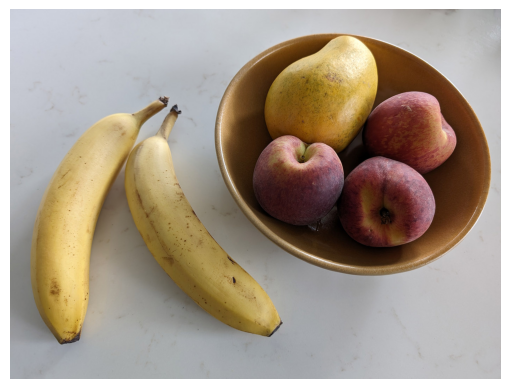

In [4]:
# Downloads the image and returns the local file path
import keras
import matplotlib.pyplot as plt

path = keras.utils.get_file(
    origin="https://s3.amazonaws.com/keras.io/img/book/fruits.jpg"
)

# Loads the image as a Python Imaging Library (PIL) object
pil_image = keras.utils.load_img(path)
# Turns the PIL object into a NumPy matrix
image_array = keras.utils.img_to_array(pil_image)

# Displays the NumPy matrix
plt.imshow(image_array.astype("uint8"))
plt.axis("off")
plt.show()

In [5]:
from keras import ops

image_size = (1024, 1024)

def resize_and_pad(x):
    return ops.image.resize(x, image_size, pad_to_aspect_ratio=True)

image = resize_and_pad(image_array)

In [7]:
image.ndim, image.shape

(3, TensorShape([1024, 1024, 3]))

In [8]:
import matplotlib.pyplot as plt
from keras import ops

def show_image(image, ax):
    ax.imshow(ops.convert_to_numpy(image).astype("uint8"))

def show_mask(mask, ax):
    color = np.array([30 / 255, 144 / 255, 255 / 255, 0.6])
    h, w, _ = mask.shape
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_points(points, ax):
    x, y = points[:, 0], points[:, 1]
    ax.scatter(x, y, c="green", marker="*", s=375, ec="white", lw=1.25)

def show_box(box, ax):
    box = box.reshape(-1)
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, ec="red", fc="none", lw=2))

### Prompting the model with a target point

To use SAM, you need to prompt it. This means we need one of the following:

Point prompts — Select a point in an image and let the model segment the object that the point belongs to.

Box prompts — Draw an approximate box around an object (it does not need to be particularly precise) and let the model segment the object in the box.

Let’s start with a point prompt. 

Points are labeled, with 1 indicating the foreground (the object you want to segment) and 0 indicating the background (everything around the object).

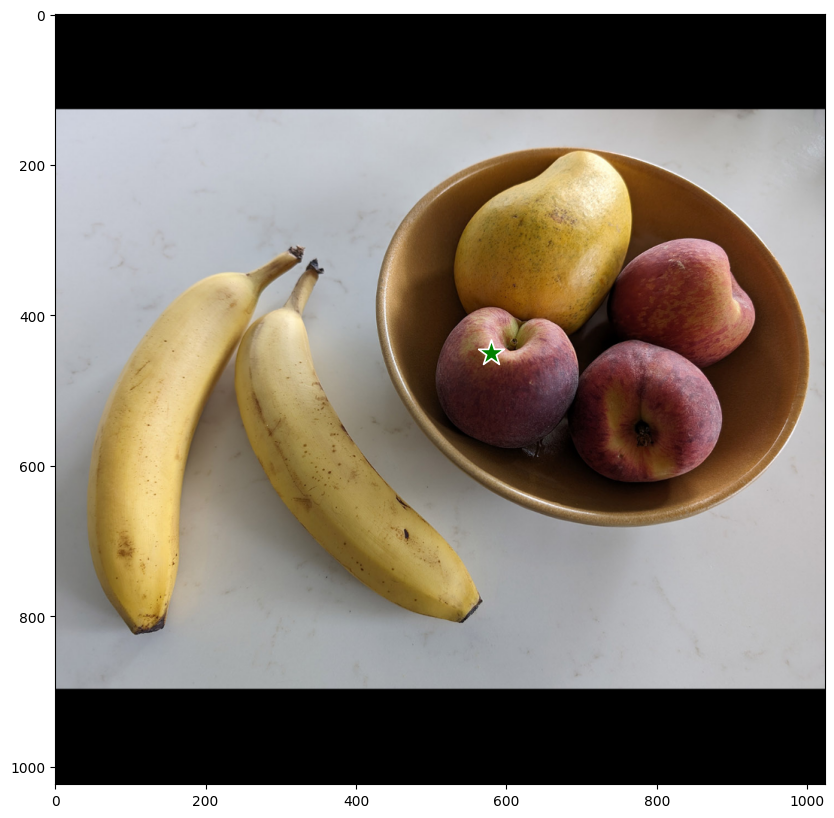

In [9]:
import numpy as np

# Coordinates of our point
input_point = np.array([[580, 450]])
# 1 means foreground, and 0 means background.
input_label = np.array([1])

plt.figure(figsize=(10, 10))
# "gca" means "get current axis" — the current figure.
show_image(image, plt.gca())
show_points(input_point, plt.gca())
plt.show()

In [13]:
outputs = model.predict(
    {
        "images": ops.expand_dims(image, axis=0),
        "points": ops.expand_dims(input_point, axis=0),
        "labels": ops.expand_dims(input_label, axis=0),
    }
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step


In [14]:
outputs["masks"].shape

(1, 4, 256, 256)

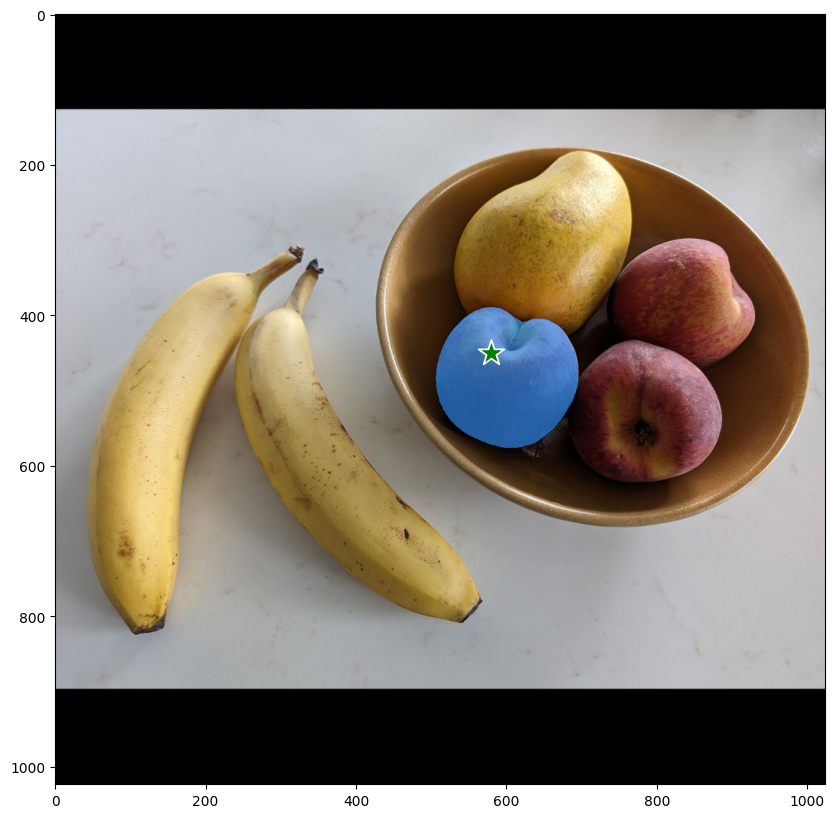

In [15]:
def get_mask(sam_outputs, index=0):
    mask = sam_outputs["masks"][0][index]
    mask = np.expand_dims(mask, axis=-1)
    mask = resize_and_pad(mask)
    return ops.convert_to_numpy(mask) > 0.0

mask = get_mask(outputs, index=0)

plt.figure(figsize=(10, 10))
show_image(image, plt.gca())
show_mask(mask, plt.gca())
show_points(input_point, plt.gca())
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 17s 17s/step


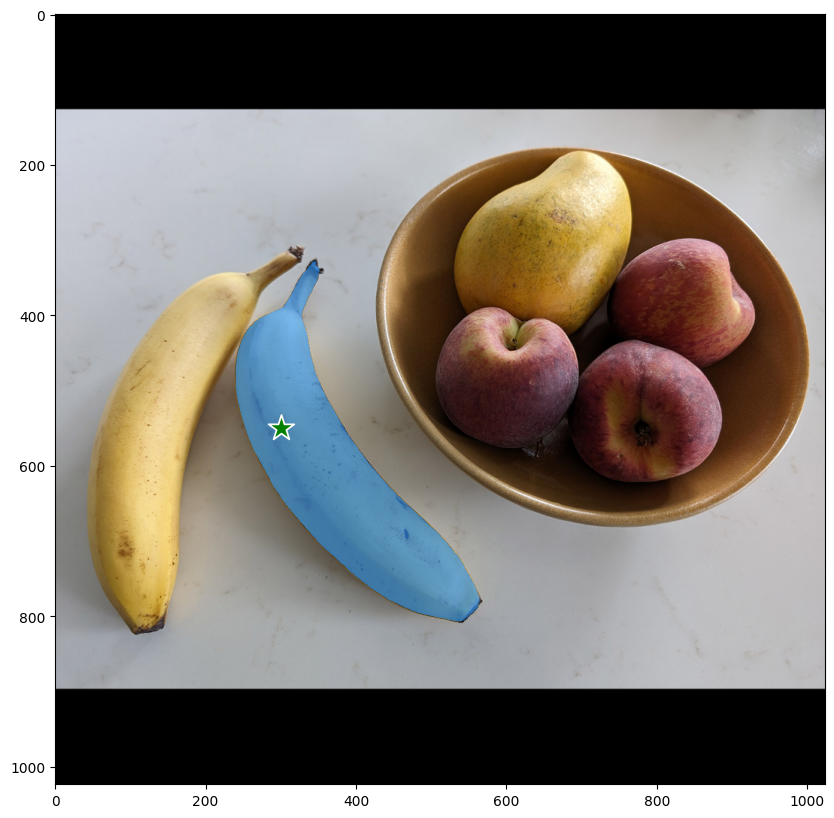

In [16]:
input_point = np.array([[300, 550]])
input_label = np.array([1])

outputs = model.predict(
    {
        "images": ops.expand_dims(image, axis=0),
        "points": ops.expand_dims(input_point, axis=0),
        "labels": ops.expand_dims(input_label, axis=0),
    }
)
mask = get_mask(outputs, index=0)

plt.figure(figsize=(10, 10))
show_image(image, plt.gca())
show_mask(mask, plt.gca())
show_points(input_point, plt.gca())
plt.show()

### Prompting the model with a target box

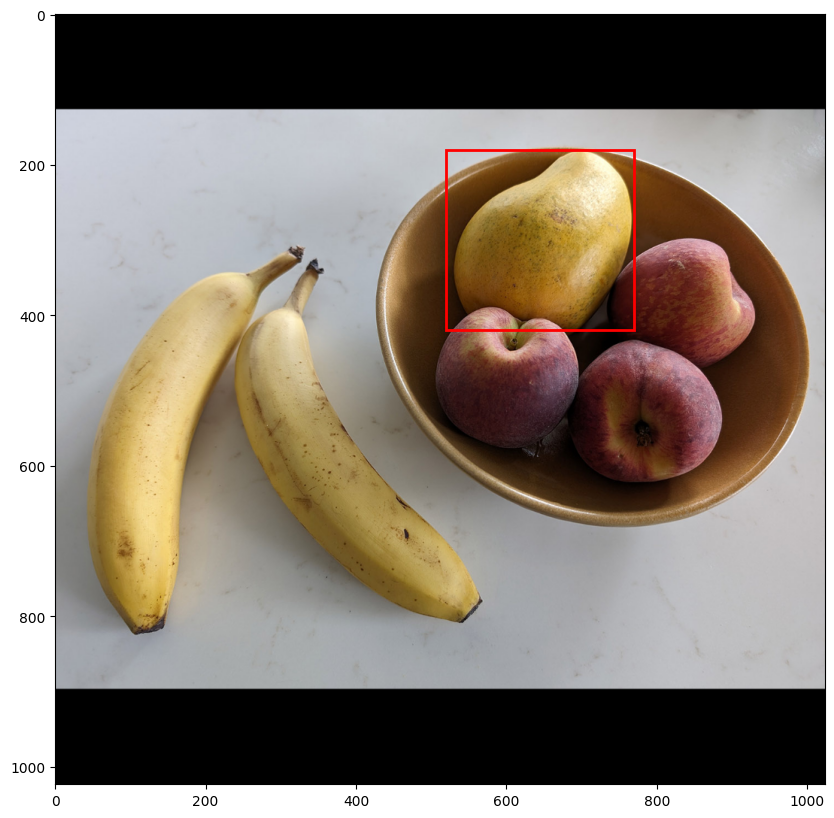

In [18]:
input_box = np.array(
    [
        # Top-left corner
        [520, 180],
        # Bottom-right corner
        [770, 420],
    ]
)

plt.figure(figsize=(10, 10))
show_image(image, plt.gca())
show_box(input_box, plt.gca())
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step


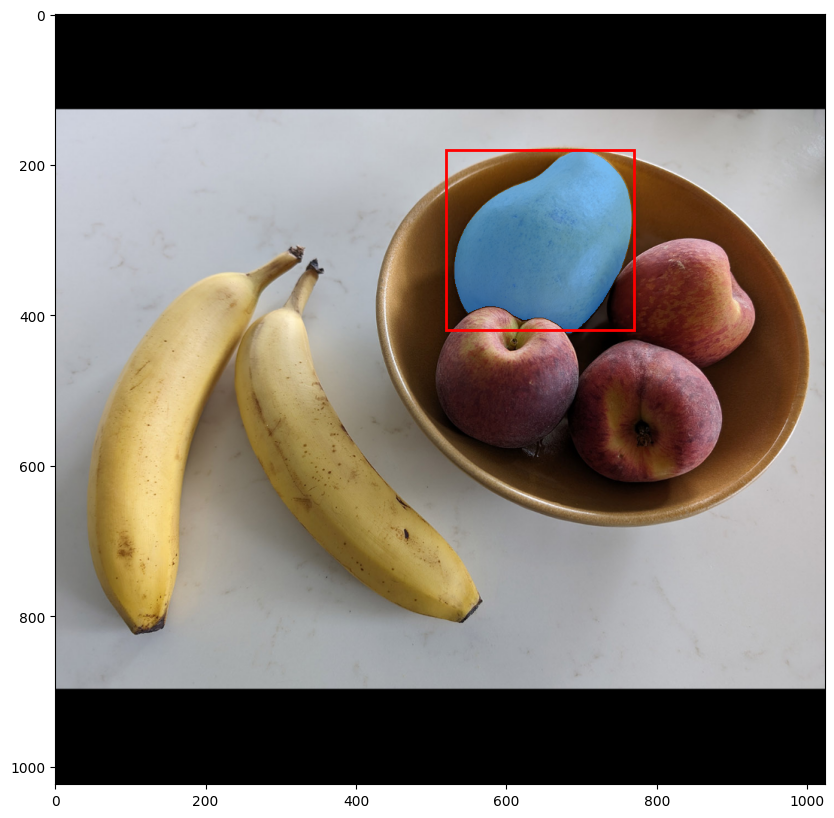

In [19]:
outputs = model.predict(
    {
        "images": ops.expand_dims(image, axis=0),
        "boxes": ops.expand_dims(input_box, axis=(0, 1)),
    }
)
mask = get_mask(outputs, 0)
plt.figure(figsize=(10, 10))
show_image(image, plt.gca())
show_mask(mask, plt.gca())
show_box(input_box, plt.gca())
plt.show()

### Summary

Image segmentation is one of the main categories of computer vision tasks. It consists of computing segmentation masks that describe the contents of an image at the pixel level.

To build your own segmentation model, use a stack of strided Conv2D layers to “compress” the input image into a smaller feature map, followed by a stack of corresponding Conv2DTranspose layers to “expand” the feature map into a segmentation mask the same size as the input image.

You can also use a pretrained segmentation model. Segment Anything, included in KerasHub, is a powerful model that supports image prompting, text prompting, point prompting, and box prompting.